In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

In [2]:
from sklearn.datasets import make_swiss_roll
x,t=make_swiss_roll(n_samples=1000,noise=0.3,random_state=1)

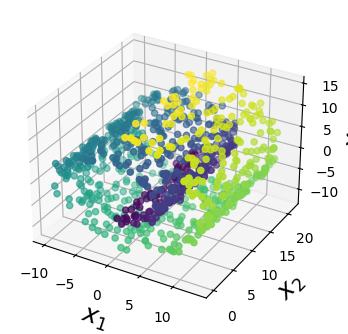

In [4]:
fig=plt.figure(figsize=(4,4))
ax=fig.add_subplot(111,projection='3d')
ax.scatter(x[:,0],x[:,1],x[:,2],c=t)
ax.set_xlabel('$x_1$',fontsize=18)
ax.set_ylabel('$x_2$',fontsize=18)
ax.set_zlabel('$x_3$',fontsize=18)
plt.show()

In [6]:
from sklearn.decomposition import KernelPCA

poly_pca=KernelPCA(n_components=2,kernel='poly',coef0=1,gamma=0.01,fit_inverse_transform=True)
z_poly=poly_pca.fit_transform(x)

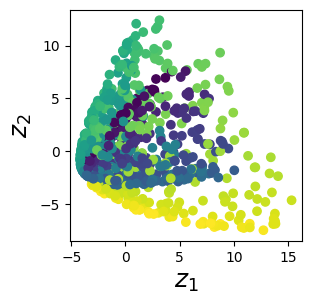

In [7]:
plt.figure(figsize=(3,3))
plt.scatter(z_poly[:,0],z_poly[:,1],c=t)
plt.xlabel('$z_1$',fontsize=18)
plt.ylabel('$z_2$',fontsize=18)
plt.show()

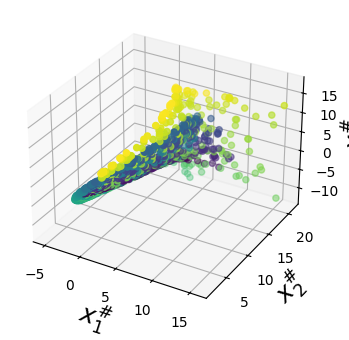

In [8]:
xp_poly=poly_pca.inverse_transform(z_poly)

plt.figure(figsize=(4,4))
ax=plt.subplot(111,projection='3d')
ax.scatter(xp_poly[:,0],xp_poly[:,1],xp_poly[:,2],c=t)
ax.set_xlabel('$x_1^\#$',fontsize=18)
ax.set_ylabel('$x_2^\#$',fontsize=18)
ax.set_zlabel('$x_3^\#$',fontsize=18)
plt.show()

In [9]:
y=t>7

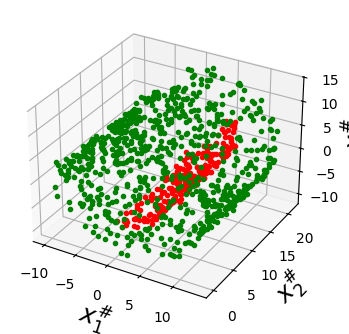

In [10]:
plt.figure(figsize=(4,4))
ax=plt.subplot(111,projection='3d')
ax.plot(x[y==0,0],x[y==0,1],x[y==0,2],"r.")
ax.plot(x[y==1,0],x[y==1,1],x[y==1,2],"g.")
ax.set_xlabel('$x_1^\#$',fontsize=18)
ax.set_ylabel('$x_2^\#$',fontsize=18)
ax.set_zlabel('$x_3^\#$',fontsize=18)
plt.show()

In [11]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

In [13]:
clf=Pipeline([
    ('kpca',KernelPCA(n_components=2,fit_inverse_transform=True)),
    ('log_reg',LogisticRegression())
])

param_grid=[{
    'kpca__gamma':np.linspace(0.01,0.06,11),
    'kpca__kernel':['rbf','sigmoid']
}]


In [14]:
grid_search=GridSearchCV(clf,param_grid,scoring='accuracy',cv=3)
grid_search.fit(x,y)
grid_search.best_params_

{'kpca__gamma': np.float64(0.045), 'kpca__kernel': 'rbf'}

In [15]:
grid_search.best_score_

np.float64(0.9029928131724537)

In [16]:
best_pca=grid_search.best_estimator_.named_steps['kpca']

In [17]:
z=best_pca.fit_transform(x)
z

array([[-0.26147759,  0.04307511],
       [ 0.07137821, -0.16452925],
       [ 0.28599387, -0.22994784],
       ...,
       [ 0.03082533, -0.18064163],
       [-0.1301833 ,  0.05965961],
       [ 0.04506277, -0.05346541]])

In [18]:
xp=best_pca.inverse_transform(z)

In [19]:
from sklearn.metrics import mean_squared_error

mean_squared_error(x,xp)

29.741749195059594